# 🏥 Lung Cancer Detection with Deep Learning 🚀

### Harnessing AI to Analyze Lung CT Scans 🔬💡




<p style='padding: 20px; background-color: #FFFFFF; color: #0044CC; font-size: 220%; text-align: center; border-radius: 10px;'>📊🩺 LUNA16 Data Exploration & Preprocessing 🏥</p>
Let's dive in! 🚀




## <span style='border-left: 4px solid #FF5733; padding-left: 10px;'> 📖 Table of Contents </span> 📌

1. 🔍 [About the LUNA Dataset](#data)
2. 🛠 [Imports & Setup](#imports)
3. 📂 [Data Loading & Overview](#loading)
4. 📊 [Data Visualization](#visualization)
5. 🔄 [Data Augmentation & Noise injection ](#preprocessing)




## 📌 1. About the LUNA16 Dataset <a id="data"></a>

### 🏥 What is LUNA16?
LUNA16 (**LUng Nodule Analysis 2016**) is a **benchmark dataset** designed for lung nodule detection using CT scans.  
It is derived from the **LIDC-IDRI dataset**, which contains **888 low-dose chest CT scans** from different patients.

The goal of LUNA16 is to **train and evaluate AI models** for:
✅ **Lung nodule detection**  
✅ **Lung cancer screening**  
✅ **Medical imaging research**  

---

### 🗂️ Dataset Structure
The dataset consists of **multiple files** categorized as follows:

📂 **CT Scans (`.mhd` & `.raw` files)**  
   - These are **3D volumetric images** of lungs captured using **low-dose CT scans**.  
   - Each `.mhd` file contains **metadata** about the scan (e.g., pixel spacing, resolution).  
   - The `.raw` file stores the **actual pixel values** in a binary format.

📜 **Annotations (`annotations.csv`)**  
   - Contains **ground truth labels** of **lung nodules** detected by radiologists.  
   - Includes the **x, y, z coordinates** of each nodule & its **diameter in mm**.  

📜 **Candidate Nodules (`candidates.csv`)**  
   - Contains **potential nodule locations** predicted by an automated system.  
   - Each row is labeled as `1` (nodule) or `0` (non-nodule).  

📜 **Splitting Information (`subsetX/` folders)**  
   - The dataset is divided into **10 subsets (`subset0` to `subset9`)** for **cross-validation**.  
   - Each subset contains a portion of CT scans.  

---

### 🔍 How to Use LUNA16 for AI Research?
To develop an AI-based **lung nodule detection system**, we need to:
1️⃣ **Load & Preprocess** the **CT scan images**  
2️⃣ **Visualize** the lung structures & nodules  
3️⃣ **Apply augmentation & noise** to enhance model generalization  
4️⃣ **Train a Deep Learning model** to detect nodules  

📢 **By following this notebook, you’ll learn step-by-step how to handle medical imaging data! 🚀**


# 🛠 2. Imports & Setup <a id="imports"></a>

In [1]:
# Import Libraries
import os
import zipfile
import pandas as pd
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import random
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure


In [2]:
# Define Dataset Directory
DATASET_PATH = r"C:\Users\ettey\Downloads\luna16"
os.makedirs(DATASET_PATH, exist_ok=True)


# 📂 3. Data Loading & Overview <a id="loading"></a>

In [3]:
# Load CSV files
annotations_file = os.path.join(DATASET_PATH, "annotations.csv")
candidates_file = os.path.join(DATASET_PATH, "candidates.csv")
submission_file = os.path.join(DATASET_PATH, "Submission.csv")

In [4]:
#Extract ZIP Files (Enhanced to Force Re-extraction)
zip_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".zip")]
for zip_file in zip_files:
    zip_path = os.path.join(DATASET_PATH, zip_file)
    extract_folder = zip_path.replace(".zip", "")
    # Force re-extraction by deleting and recreating the folder
    if os.path.exists(extract_folder):
        import shutil
        shutil.rmtree(extract_folder)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)
    print(f"Re-extracted: {zip_file}")
print("All ZIP files re-extracted successfully.")

Re-extracted: candidates_V2.zip
Re-extracted: evaluationScript.zip
Re-extracted: seg-lungs-LUNA16.zip
Re-extracted: subset0.zip
Re-extracted: subset1.zip
Re-extracted: subset2.zip
Re-extracted: subset3 (1).zip
Re-extracted: subset4.zip
Re-extracted: subset5.zip
Re-extracted: subset6.zip
Re-extracted: subset7.zip
Re-extracted: subset8.zip
Re-extracted: subset9.zip
All ZIP files re-extracted successfully.


# 📊 4. Data Visualization <a id="visualization"></a>


In [6]:
#Read CSV Files
annotations = pd.read_csv(annotations_file)
print("Annotations loaded. Total nodules:", len(annotations))
print(annotations.head())

Annotations loaded. Total nodules: 1186
                                           seriesuid      coordX      coordY  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222... -128.699421 -175.319272   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.783651 -211.925149   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...   69.639017 -140.944586   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...  -24.013824  192.102405   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...    2.441547  172.464881   

       coordZ  diameter_mm  
0 -298.387506     5.651471  
1 -227.121250     4.224708  
2  876.374496     5.786348  
3 -391.081276     8.143262  
4 -405.493732    18.545150  


In [7]:
# Read candidates CSV (contains possible nodule locations)
candidates = pd.read_csv(candidates_file)
print("Candidates loaded. Total candidate locations:", len(candidates))
print(candidates.head())


Candidates loaded. Total candidate locations: 551065
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  


In [39]:
# Candidates vs. Actual Nodules (Dynamic Slice Selection with Proper Filtering)
nodule_slices = []
for idx, nodule in annotations.iterrows():
    voxel_coords = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
    z, y, x = voxel_coords  # SimpleITK array is [z, y, x]
    print(f"Nodule {idx} at world (x, y, z): ({nodule['coordX']}, {nodule['coordY']}, {nodule['coordZ']}), "
          f"voxel (x, y, z): ({x}, {y}, {z})")
    if 0 <= z < array.shape[0]:  # Ensure z is within the valid range of slices
        nodule_slices.append(z)

if not nodule_slices:
    print("No nodules found in any valid slice. Check the transformation or annotations.csv data.")
else:
    # Select a slice with a nodule (e.g., the first valid one)
    slice_index = nodule_slices[0]
    print(f"Selected slice_index {slice_index} with at least one nodule.")

Nodule 0 at world (x, y, z): (-128.6994211, -175.3192718, -298.3875064), voxel (x, y, z): (48, 43, 89)
Nodule 1 at world (x, y, z): (103.7836509, -211.9251487, -227.12125), voxel (x, y, z): (105, -8, 420)
Nodule 2 at world (x, y, z): (69.63901724, -140.9445859, 876.3744957), voxel (x, y, z): (988, 92, 371)
Nodule 3 at world (x, y, z): (-24.0138242, 192.1024053, -391.0812764), voxel (x, y, z): (-25, 566, 238)
Nodule 4 at world (x, y, z): (2.441546798, 172.4648812, -405.4937318), voxel (x, y, z): (-37, 538, 276)
Nodule 5 at world (x, y, z): (90.93171321, 149.0272657, -426.5447146), voxel (x, y, z): (-54, 504, 402)
Nodule 6 at world (x, y, z): (89.54076865, 196.4051593, -515.0733216), voxel (x, y, z): (-124, 572, 400)
Nodule 7 at world (x, y, z): (81.50964574, 54.9572186, -150.3464233), voxel (x, y, z): (166, 371, 388)
Nodule 8 at world (x, y, z): (105.0557924, 19.82526014, -91.24725078), voxel (x, y, z): (214, 321, 422)
Nodule 9 at world (x, y, z): (-124.8342624, 127.2471546, -473.064478

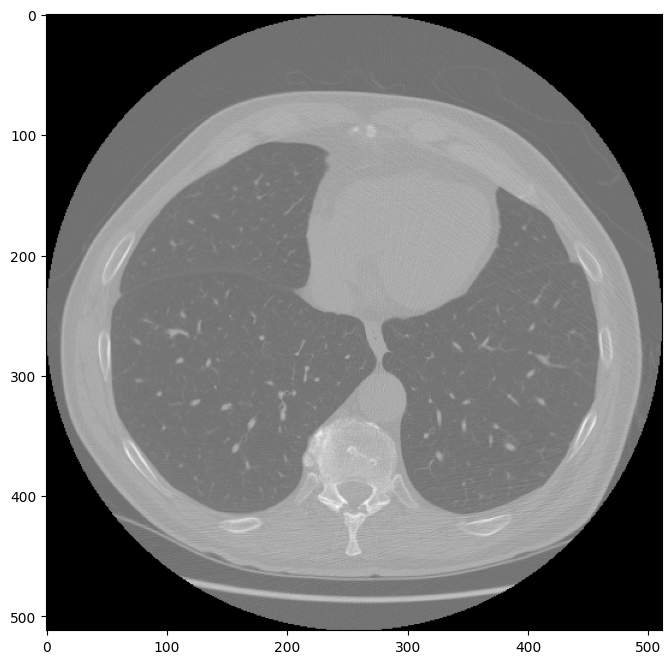

In [41]:
# Plot the selected slice
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(array[slice_index], cmap='gray')

In [55]:
nodule_coords = []
for idx, nodule in annotations.iterrows():
    voxel_coords = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
    z, y, x = voxel_coords
    if z == slice_index and 0 <= x < array.shape[2] and 0 <= y < array.shape[1]:
        nodule_coords.append((x, y))

# Plot actual nodules
if nodule_coords:
    x_nodules, y_nodules = zip(*nodule_coords)
    ax.scatter(x_nodules, y_nodules, c='red', marker='x', label='Actual Nodule', s=100, alpha=0.8)
else:
    print("Unexpected: No nodules found after slice selection. Check transformation logic.")


In [58]:
# Collect candidates for the selected slice
candidate_coords = []
for idx, candidate in candidates.iterrows():
        voxel_coords = ((np.array([candidate['coordX'], candidate['coordY'], candidate['coordZ']]) - origin) / spacing).astype(int)
        z, y, x = voxel_coords
        if z == slice_index and 0 <= x < array.shape[2] and 0 <= y < array.shape[1]:
            candidate_coords.append((x, y))
            if len(candidate_coords) > 50:  # Limit for clarity
                break

In [62]:
# Plot candidates
if candidate_coords:
    x_candidates, y_candidates = zip(*candidate_coords)
    ax.scatter(x_candidates, y_candidates, c='blue', marker='o', label='Candidate', s=50, alpha=0.5)
else:
    print(f"No candidates found at slice_index {slice_index}")

ax.set_title(f"Candidates vs. Actual Nodules (Slice {slice_index})")
ax.axis("off")
ax.legend()
plt.show()


In [63]:
# Cell 15: Visualize Nodules and Candidates
# Debug origin and spacing for verification
print("CT Shape (z, y, x):", array.shape)
print("Spacing (x, y, z):", spacing)
print("Origin (x, y, z):", origin)

CT Shape (z, y, x): (256, 512, 512)
Spacing (x, y, z): [0.703125 0.703125 1.25    ]
Origin (x, y, z): [-191.899994 -206.       -359.      ]


In [67]:
    # Collect actual nodules for the selected slice
    nodule_coords = []
    for idx, nodule in annotations.iterrows():
        voxel_coords = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
        z, y, x = voxel_coords
        if z == slice_index and 0 <= x < array.shape[2] and 0 <= y < array.shape[1]:
            nodule_coords.append((x, y))
            print(f"Nodule {idx} added at voxel (x, y): ({x}, {y})")

  

Nodule 0 added at voxel (x, y): (48, 43)
Nodule 85 added at voxel (x, y): (223, 275)
Nodule 810 added at voxel (x, y): (250, 366)
Nodule 840 added at voxel (x, y): (116, 290)


In [71]:
# Plot actual nodules
if nodule_coords:
    x_nodules, y_nodules = zip(*nodule_coords)
    ax.scatter(x_nodules, y_nodules, c='red', marker='x', label='Actual Nodule', s=100, alpha=0.8)
    print(f"Plotted {len(nodule_coords)} nodules")
else:
    print("Unexpected: No nodules found after slice selection. Check transformation logic.")


Plotted 4 nodules


In [73]:
    # Collect candidates for the selected slice
    candidate_coords = []
    for idx, candidate in candidates.iterrows():
        voxel_coords = ((np.array([candidate['coordX'], candidate['coordY'], candidate['coordZ']]) - origin) / spacing).astype(int)
        z, y, x = voxel_coords
        if z == slice_index and 0 <= x < array.shape[2] and 0 <= y < array.shape[1]:
            candidate_coords.append((x, y))
            print(f"Candidate {idx} added at voxel (x, y): ({x}, {y})")
            if len(candidate_coords) > 50:  # Limit for clarity
                break

 

Candidate 78 added at voxel (x, y): (48, 44)
Candidate 277 added at voxel (x, y): (13, 120)
Candidate 310 added at voxel (x, y): (15, 126)
Candidate 8428 added at voxel (x, y): (64, 333)
Candidate 9496 added at voxel (x, y): (140, 299)
Candidate 11793 added at voxel (x, y): (145, 270)
Candidate 12140 added at voxel (x, y): (69, 260)
Candidate 12497 added at voxel (x, y): (89, 262)
Candidate 12639 added at voxel (x, y): (119, 293)
Candidate 12662 added at voxel (x, y): (103, 299)
Candidate 12681 added at voxel (x, y): (133, 298)
Candidate 13796 added at voxel (x, y): (94, 359)
Candidate 15065 added at voxel (x, y): (110, 266)
Candidate 17015 added at voxel (x, y): (218, 363)
Candidate 17182 added at voxel (x, y): (182, 327)
Candidate 20141 added at voxel (x, y): (153, 303)
Candidate 20257 added at voxel (x, y): (146, 296)
Candidate 24192 added at voxel (x, y): (186, 273)
Candidate 24527 added at voxel (x, y): (163, 311)
Candidate 24578 added at voxel (x, y): (192, 297)
Candidate 24725 a

In [77]:
# Plot candidates
if candidate_coords:
    x_candidates, y_candidates = zip(*candidate_coords)
    ax.scatter(x_candidates, y_candidates, c='blue', marker='o', label='Candidate', s=50, alpha=0.5)
    print(f"Plotted {len(candidate_coords)} candidates")
else:
    print(f"No candidates found at slice_index {slice_index}")

ax.set_title(f"Candidates vs. Actual Nodules (Slice {slice_index})")
ax.axis("off")
ax.legend()
plt.show()
print("Plot displayed")


Plotted 51 candidates
Plot displayed


In [82]:
# Cell 8: Display All Files and Directories in the luna16 Folder
import os

# Define the dataset path
DATASET_PATH = r"C:\Users\ettey\Downloads\luna16"

# List all items in the luna16 folder
print(f"Contents of {DATASET_PATH}:")
for item in os.listdir(DATASET_PATH):
    item_path = os.path.join(DATASET_PATH, item)
    if os.path.isfile(item_path):
        print(f"  File: {item}")
    else:
        print(f"  Directory: {item}")

# Optional: Count total items
total_items = len(os.listdir(DATASET_PATH))
print(f"\nTotal items found: {total_items}")

Contents of C:\Users\ettey\Downloads\luna16:
  File: annotations.csv
  File: candidates.csv
  Directory: candidates_V2
  File: candidates_V2.zip
  Directory: evaluationScript
  File: evaluationScript.zip
  Directory: processed
  Directory: processed_images
  File: sampleSubmission.csv
  Directory: seg-lungs-LUNA16
  File: seg-lungs-LUNA16.zip
  Directory: subset0
  File: subset0.zip
  Directory: subset1
  File: subset1.zip
  Directory: subset2
  File: subset2.zip
  Directory: subset3
  Directory: subset3 (1)
  File: subset3 (1).zip
  Directory: subset4
  File: subset4.zip
  Directory: subset5
  File: subset5.zip
  Directory: subset6
  File: subset6.zip
  Directory: subset7
  File: subset7.zip
  Directory: subset8
  File: subset8.zip
  Directory: subset9
  File: subset9.zip

Total items found: 32


In [17]:
#Find and Select All MHD Files (Enhanced Recursive Logic)
import fnmatch
mhd_files = []
expected_subsets = [f"subset{i}" for i in range(10)]  # LUNA16 has 10 subsets (0-9)
print(f"Expected subsets: {expected_subsets}")

def find_mhd_files(directory):
    mhd_files_list = []
    for root, dirs, files in os.walk(directory):
        for file in fnmatch.filter(files, "*.mhd"):
            full_path = os.path.join(root, file)
            mhd_files_list.append(full_path)
    print(f"  Found: {full_path}")
    return mhd_files_list

for subset in os.listdir(DATASET_PATH):
    subset_path = os.path.join(DATASET_PATH, subset)
    if os.path.isdir(subset_path) and subset in expected_subsets:
        print(f"Scanning subset: {subset}")
        subset_mhd_files = find_mhd_files(subset_path)
        mhd_files.extend(subset_mhd_files)
        print(f"  Total .mhd files in {subset}: {len(subset_mhd_files)}")
    else:
        print(f"Skipping {subset} (not a recognized subset folder)")

if not mhd_files:
    print("No .mhd files found. Ensure all subset ZIP files are downloaded and extracted correctly.")
    raise FileNotFoundError("No .mhd files found!")
else:
    print(f"Found {len(mhd_files)} .mhd files across all subsets.")


Expected subsets: ['subset0', 'subset1', 'subset2', 'subset3', 'subset4', 'subset5', 'subset6', 'subset7', 'subset8', 'subset9']
Scanning subset: subset0
  Total .mhd files in subset0: 89
Scanning subset: subset1
  Total .mhd files in subset1: 89
Scanning subset: subset2
  Total .mhd files in subset2: 89
Scanning subset: subset3
  Total .mhd files in subset3: 89
Scanning subset: subset4
  Total .mhd files in subset4: 89
Scanning subset: subset5
  Total .mhd files in subset5: 89
Scanning subset: subset6
  Total .mhd files in subset6: 89
Scanning subset: subset7
  Total .mhd files in subset7: 89
Scanning subset: subset8
  Total .mhd files in subset8: 88
Scanning subset: subset9
  Total .mhd files in subset9: 88
Found 888 .mhd files across all subsets.


Expected subsets: ['subset0', 'subset1', 'subset2', 'subset3', 'subset4', 'subset5', 'subset6', 'subset7', 'subset8', 'subset9']
Skipping annotations.csv (not a recognized subset folder)
Skipping candidates.csv (not a recognized subset folder)
Skipping candidates_V2 (not a recognized subset folder)
Skipping candidates_V2.zip (not a recognized subset folder)
Skipping evaluationScript (not a recognized subset folder)
Skipping evaluationScript.zip (not a recognized subset folder)
Skipping processed (not a recognized subset folder)
Skipping processed_images (not a recognized subset folder)
Skipping sampleSubmission.csv (not a recognized subset folder)
Skipping seg-lungs-LUNA16 (not a recognized subset folder)
Skipping seg-lungs-LUNA16.zip (not a recognized subset folder)
Scanning subset: subset0
  Found: C:\Users\ettey\Downloads\luna16\subset0\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260.mhd
  Found: C:\Users\ettey\Downloads\luna16\subset0\subset0\1.3.6.1.4.1.14

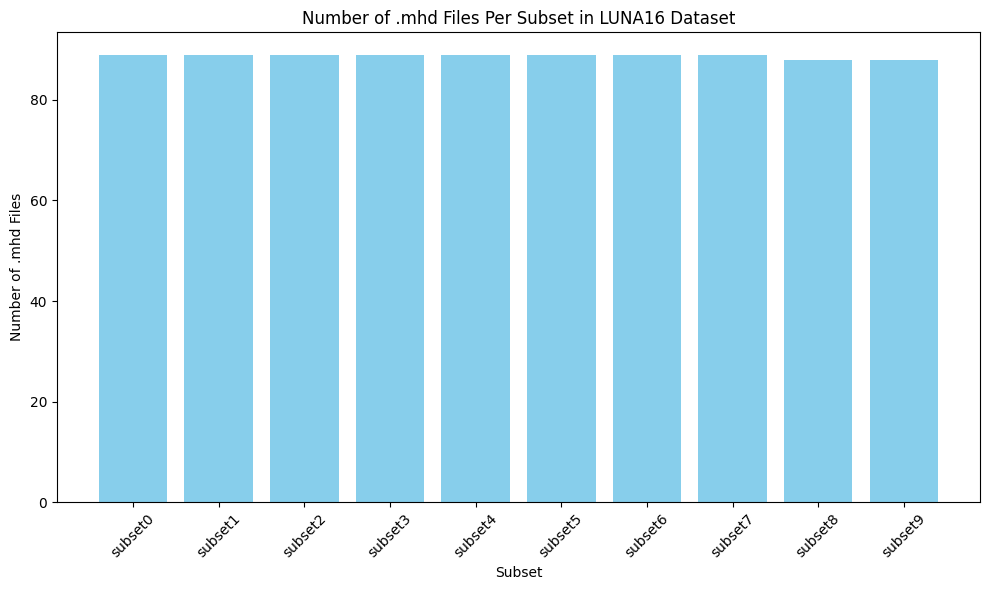

In [30]:
import fnmatch

mhd_files = []
subsets = []
counts = []  # List to store counts for plotting
expected_subsets = [f"subset{i}" for i in range(10)]  # LUNA16 has 10 subsets (0-9)
print(f"Expected subsets: {expected_subsets}")

def find_mhd_files(directory):
    mhd_files_list = []
    for root, dirs, files in os.walk(directory):
        for file in fnmatch.filter(files, "*.mhd"):
            full_path = os.path.join(root, file)
            mhd_files_list.append(full_path)
            print(f"  Found: {full_path}")
    return mhd_files_list

for subset in os.listdir(DATASET_PATH):
    subset_path = os.path.join(DATASET_PATH, subset)
    if os.path.isdir(subset_path) and subset in expected_subsets:
        print(f"Scanning subset: {subset}")
        subset_mhd_files = find_mhd_files(subset_path)
        mhd_files.extend(subset_mhd_files)
        subsets.append(subset)  # Store subset name
        counts.append(len(subset_mhd_files))  # Store count for this subset
        # Removed: print(f"  Total .mhd files in {subset}: {len(subset_mhd_files)}")
    else:
        print(f"Skipping {subset} (not a recognized subset folder)")

if not mhd_files:
    print("No .mhd files found. Ensure all subset ZIP files are downloaded and extracted correctly.")
    raise FileNotFoundError("No .mhd files found!")
else:
    print(f"Found {len(mhd_files)} .mhd files across all subsets.")

# Plot the counts as a bar chart
plt.figure(figsize=(10, 6))
plt.bar(subsets, counts, color='skyblue')
plt.xlabel("Subset")
plt.ylabel("Number of .mhd Files")
plt.title("Number of .mhd Files Per Subset in LUNA16 Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

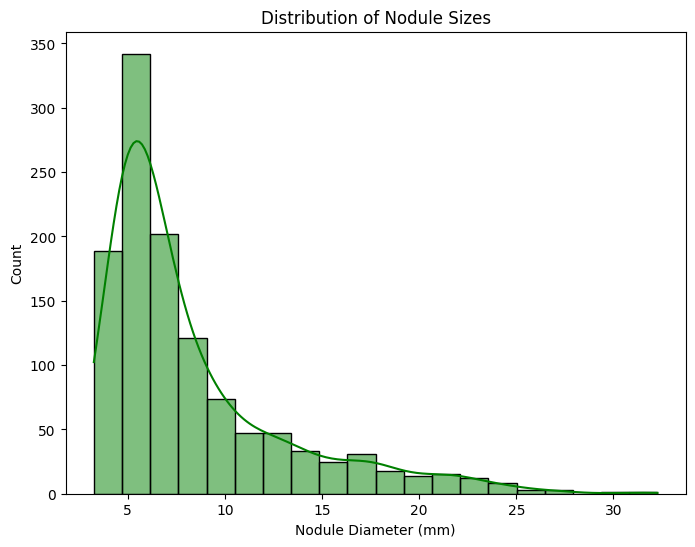

In [35]:
# Cell 17: Nodule Size Distribution
import seaborn as sns  
plt.figure(figsize=(8, 6))
sns.histplot(annotations['diameter_mm'], bins=20, kde=True, color='green')
plt.xlabel("Nodule Diameter (mm)")
plt.ylabel("Count")
plt.title("Distribution of Nodule Sizes")
plt.show()

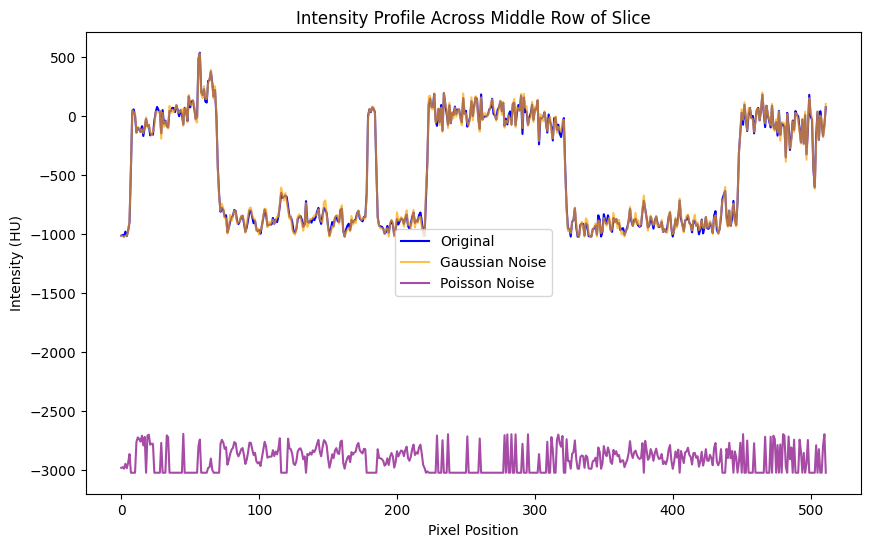

In [36]:
# Cell 18: Intensity Profile Across a Slice
plt.figure(figsize=(10, 6))
mid_row = array[slice_index, array.shape[1] // 2, :]
plt.plot(mid_row, label='Original', color='blue')
plt.plot(gaussian_noisy_array[slice_index, array.shape[1] // 2, :], label='Gaussian Noise', color='orange', alpha=0.7)
plt.plot(poisson_noisy_array[slice_index, array.shape[1] // 2, :], label='Poisson Noise', color='purple', alpha=0.7)
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (HU)")
plt.title("Intensity Profile Across Middle Row of Slice")
plt.legend()
plt.show()

In [72]:
# Collect candidates with proper coordinate transformation
candidate_coords = []
for idx, candidate in candidates.iterrows():
    voxel_coords = ((np.array([candidate['coordX'], candidate['coordY'], candidate['coordZ']]) - origin) / spacing).astype(int)
    z, y, x = voxel_coords  # SimpleITK array is [z, y, x]
    if z == slice_index and 0 <= x < array.shape[2] and 0 <= y < array.shape[1]:
        candidate_coords.append((x, y))
        if len(candidate_coords) > 50:
            break

# Plot candidates
if candidate_coords:
    x_candidates, y_candidates = zip(*candidate_coords)
    ax.scatter(x_candidates, y_candidates, c='blue', marker='o', label='Candidate', s=50, alpha=0.5)
else:
    print(f"No candidates found at slice_index {slice_index}")

ax.set_title("Candidates vs. Actual Nodules")
ax.axis("off")
ax.legend()
plt.show()

reader = sitk.ImageFileReader()
reader.SetFileName(random.choice(mhd_files))  # Use a random file from mhd_files
reader.SetImageIO("MetaImageIO")
image = reader.Execute()
array = sitk.GetArrayFromImage(image)
spacing = np.array(image.GetSpacing())
origin = np.array(image.GetOrigin())
print("CT Scan Shape (Depth, Height, Width):", array.shape)

# 5. 🎭 Data Augmentation & Noise Injection

In [20]:
# Cell 11: Noise Injection Functions
def add_gaussian_noise(image_array, mean=0, std=25):
    """Add Gaussian noise to simulate sensor noise."""
    noise = np.random.normal(mean, std, image_array.shape)
    noisy_image = image_array + noise
    return np.clip(noisy_image, -1024, 3071)  # Typical CT Hounsfield Unit range

In [21]:
def add_poisson_noise(image_array):
    """Add Poisson noise to simulate low-dose CT scans."""
    # Replace NaNs with 0
    cleaned_array = np.nan_to_num(image_array, nan=0.0)
    print(f"Min before shift: {cleaned_array.min()}, Max before shift: {cleaned_array.max()}")
    # Shift to positive range and ensure non-negative
    shifted_array = cleaned_array - cleaned_array.min()
    shifted_array = np.clip(shifted_array, 0, None)  # Redundant but ensures safety
    print(f"Min after shift: {shifted_array.min()}, Max after shift: {shifted_array.max()}")
    # Scale and clip to prevent overflow
    scaled_array = np.clip(shifted_array * 100, 0, 1e6)
    print(f"Min after scaling: {scaled_array.min()}, Max after scaling: {scaled_array.max()}")
    # Apply Poisson noise
    noisy_image = np.random.poisson(scaled_array) / 100
    return noisy_image + cleaned_array.min()

In [22]:
# Noise Injection Implementation
# Define output directory for processed images
OUTPUT_PATH = os.path.join(DATASET_PATH, "processed_images")
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "normal"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "gaussian"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "poisson"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "both"), exist_ok=True)

In [23]:
# Process each CT scan with noise injection
for idx, ct_file in enumerate(mhd_files[:10]):  # Process first 10 files as an example
    # Load CT image
    image = sitk.ReadImage(ct_file)
    array_3d = sitk.GetArrayFromImage(image)
    
    # Process each 2D slice
    for slice_idx in range(array_3d.shape[0]):
        slice_2d = array_3d[slice_idx]
        total_slices = len(mhd_files) * array_3d.shape[0]
        slice_percentage = (idx * array_3d.shape[0] + slice_idx) / total_slices

        if slice_percentage <= 0.4:  # 40% Normal
            output_folder = os.path.join(OUTPUT_PATH, "normal")
            noisy_slice = slice_2d
        elif slice_percentage <= 0.7:  # 30% Gaussian
            output_folder = os.path.join(OUTPUT_PATH, "gaussian")
            noisy_slice = add_gaussian_noise(slice_2d, mean=0, std=15)
        elif slice_percentage <= 0.9:  # 20% Poisson
            output_folder = os.path.join(OUTPUT_PATH, "poisson")
            noisy_slice = add_poisson_noise(slice_2d)
        else:  # 10% Both
            output_folder = os.path.join(OUTPUT_PATH, "both")
            noisy_slice = add_poisson_noise(add_gaussian_noise(slice_2d, mean=0, std=15))

        # Save the processed slice (clip to valid HU range)
        output_file = os.path.join(output_folder, f"{os.path.splitext(os.path.basename(ct_file))[0]}_slice_{slice_idx}.npy")
        np.save(output_file, np.clip(noisy_slice, -1024, 3071))

print("Noise injection and data preparation completed!")

Noise injection and data preparation completed!


Min before shift: -3024, Max before shift: 1476
Min after shift: 0, Max after shift: 4500
Min after scaling: 0.0, Max after scaling: 32756.0
Min before shift: -1024.0, Max before shift: 1475.2419807864233
Min after shift: 0.0, Max after shift: 2499.2419807864235
Min after scaling: 0.0, Max after scaling: 249924.19807864234


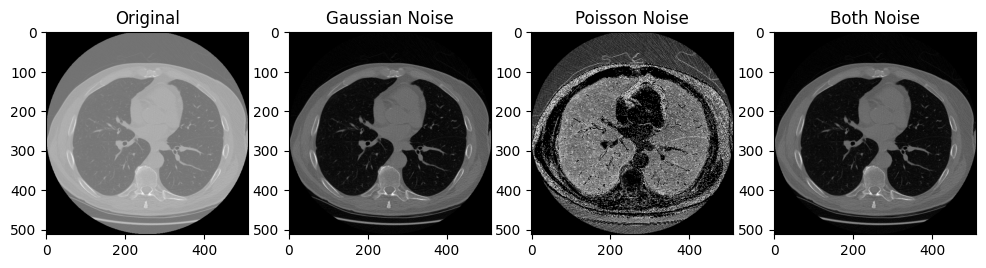

In [26]:
# Visualize a sample slice with different noise types
sample_slice = array[array.shape[0] // 2]  # Middle slice for visualization
gaussian_sample = add_gaussian_noise(sample_slice, mean=0, std=15)
poisson_sample = add_poisson_noise(sample_slice)
both_sample = add_poisson_noise(add_gaussian_noise(sample_slice, mean=0, std=15))

plt.figure(figsize=(12, 4))
plt.subplot(141), plt.imshow(sample_slice, cmap='gray'), plt.title('Original')
plt.subplot(142), plt.imshow(gaussian_sample, cmap='gray'), plt.title('Gaussian Noise')
plt.subplot(143), plt.imshow(poisson_sample, cmap='gray'), plt.title('Poisson Noise')
plt.subplot(144), plt.imshow(both_sample, cmap='gray'), plt.title('Both Noise')
plt.show()

In [27]:
#Apply Noise to Sample Array
gaussian_noisy_array = add_gaussian_noise(array)
poisson_noisy_array = add_poisson_noise(array)

Min before shift: -3024, Max before shift: 2210
Min after shift: 0, Max after shift: 5234
Min after scaling: 0.0, Max after scaling: 32756.0


In [ ]:
 # Overlay a nodule location on the CT scan if available
if len(annotations) > 0:
        nodule = annotations.iloc[0]  # Select the first nodule
        x, y, z = int(nodule["coordX"]), int(nodule["coordY"]), int(nodule["coordZ"])

        # Convert world coordinates to voxel space
        spacing = np.array(image.GetSpacing())
        origin = np.array(image.GetOrigin())
        x_voxel, y_voxel, z_voxel = ((np.array([x, y, z]) - origin) / spacing).astype(int)

        # Plot the nodule location on the scan
        plt.imshow(array[z_voxel], cmap="gray")
        plt.scatter(x_voxel, y_voxel, c="red", marker="x")
        plt.title(f"Nodule at (X: {x}, Y: {y}, Z: {z})")
        plt.axis("off")
        plt.show()
else:
        print("No nodules found in annotations.")


In [37]:
# Find .mhd files
mhd_files = []
for subset in os.listdir(DATASET_PATH):
    subset_path = os.path.join(DATASET_PATH, subset)
    if os.path.isdir(subset_path):
        for file in os.listdir(subset_path):
            if file.lower().endswith(".mhd"):
                mhd_files.append(os.path.join(subset_path, file))
if not mhd_files:
    print("No .mhd files found!")
else:
    sample_scan = random.choice(mhd_files)
    print(f"Selected CT scan: {sample_scan}")

    # Load scan
    image = sitk.ReadImage(sample_scan)
    array = sitk.GetArrayFromImage(image)
    spacing = np.array(image.GetSpacing())
    origin = np.array(image.GetOrigin())

Selected CT scan: C:\Users\ettey\Downloads\luna16\subset0\1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651233986592378348912.mhd


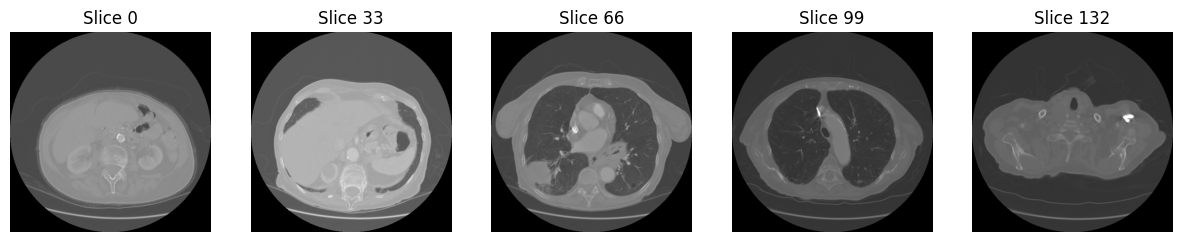

In [42]:
# 1️⃣ Multiple Slices Visualization (Fixed)
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
slice_indices = np.linspace(0, array.shape[0] - 1, 5, dtype=int)  # Ensures 5 valid indices

for i, idx in enumerate(slice_indices):
    axes[i].imshow(array[idx], cmap='gray')
    axes[i].set_title(f"Slice {idx}")
    axes[i].axis("off")

plt.show()


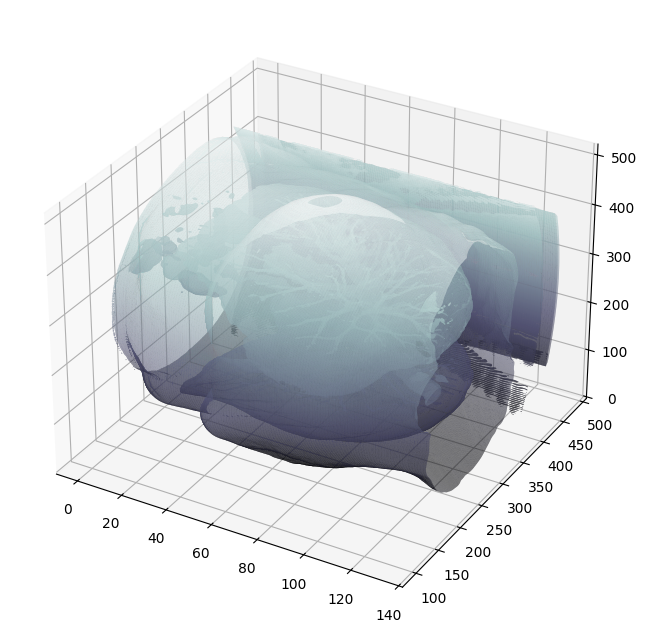

In [43]:
import random
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
# 2️⃣ 3D Visualization
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
verts, faces, _, _ = measure.marching_cubes(array, level=-400)
ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2], cmap='bone', alpha=0.7)
plt.show()

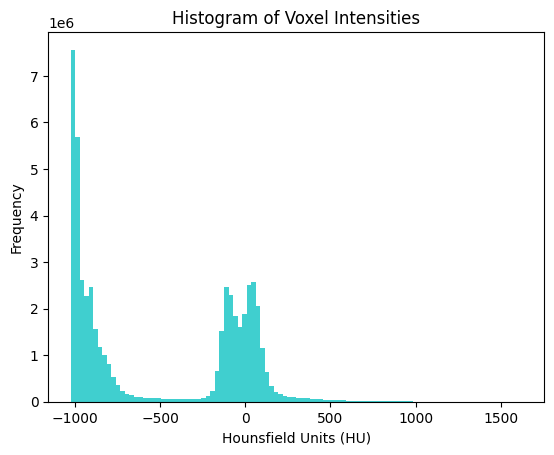

In [27]:
 # 3️⃣ Histogram of Voxel Intensities
plt.hist(array.flatten(), bins=100, color='c', alpha=0.75)
plt.xlabel("Hounsfield Units (HU)")
plt.ylabel("Frequency")
plt.title("Histogram of Voxel Intensities")
plt.show()

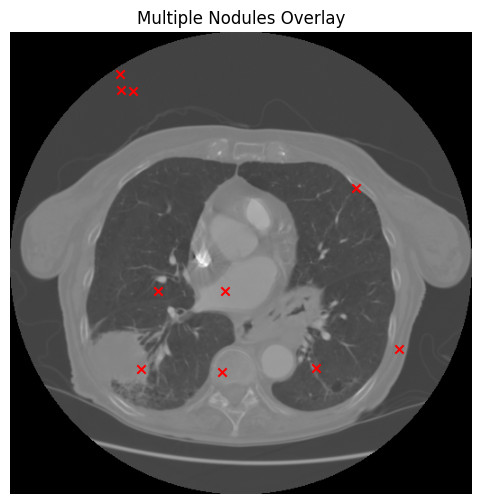

In [44]:
# 4️⃣ Overlay Multiple Nodules (Fixed)
fig, ax = plt.subplots(figsize=(6, 6))
slice_index = array.shape[0] // 2  # Middle slice
ax.imshow(array[slice_index], cmap='gray')

for _, nodule in annotations.iterrows():
    x, y, z = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
    
    # Only mark nodules that are in the current slice
    if z == slice_index:
        ax.scatter(x, y, c='red', marker='x')

ax.set_title("Multiple Nodules Overlay")
ax.axis("off")
plt.show()


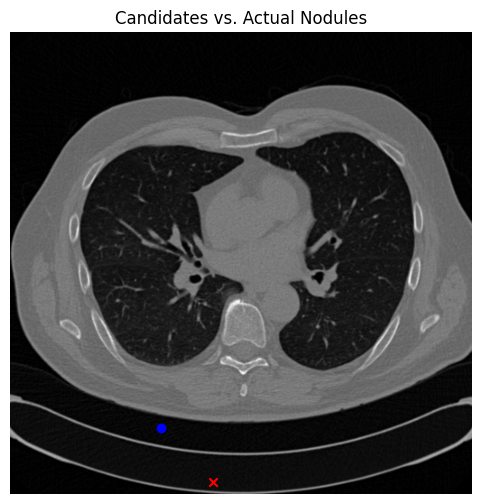

In [36]:
  # 5️⃣ Candidates vs. Actual Nodules
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(array[slice_index], cmap='gray')
for _, nodule in annotations.iterrows():
        x, y, z = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
ax.scatter(x, y, c='red', marker='x', label='Actual Nodule')
for _, candidate in candidates.iterrows():
        x, y, z = ((np.array([candidate['coordX'], candidate['coordY'], candidate['coordZ']]) - origin) / spacing).astype(int)
ax.scatter(x, y, c='blue', marker='o', label='Candidate')
ax.set_title("Candidates vs. Actual Nodules")
ax.axis("off")
plt.show()


noise injection 

CT Shape (z, y, x): (256, 512, 512)
Spacing (x, y, z): [0.703125 0.703125 1.25    ]
Origin (x, y, z): [-191.899994 -206.       -359.      ]
Nodule 0 at world (x, y, z): (-128.6994211, -175.3192718, -298.3875064), voxel (x, y, z): (48, 43, 89)
Nodule 1 at world (x, y, z): (103.7836509, -211.9251487, -227.12125), voxel (x, y, z): (105, -8, 420)
Nodule 2 at world (x, y, z): (69.63901724, -140.9445859, 876.3744957), voxel (x, y, z): (988, 92, 371)
Nodule 3 at world (x, y, z): (-24.0138242, 192.1024053, -391.0812764), voxel (x, y, z): (-25, 566, 238)
Nodule 4 at world (x, y, z): (2.441546798, 172.4648812, -405.4937318), voxel (x, y, z): (-37, 538, 276)
Nodule 5 at world (x, y, z): (90.93171321, 149.0272657, -426.5447146), voxel (x, y, z): (-54, 504, 402)
Nodule 6 at world (x, y, z): (89.54076865, 196.4051593, -515.0733216), voxel (x, y, z): (-124, 572, 400)
Nodule 7 at world (x, y, z): (81.50964574, 54.9572186, -150.3464233), voxel (x, y, z): (166, 371, 388)
Nodule 8 at world (x, y, z): (10

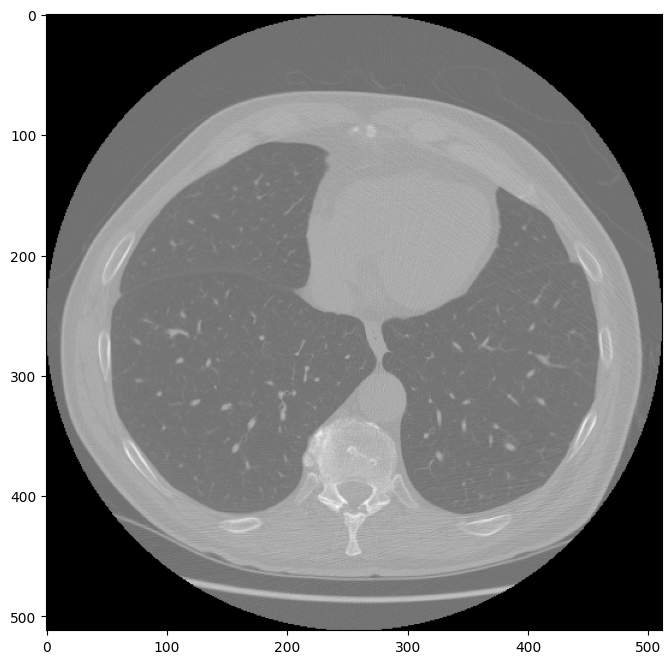

In [78]:
# Cell 15: Visualize Nodules and Candidates
# Debug origin and spacing for verification
print("CT Shape (z, y, x):", array.shape)
print("Spacing (x, y, z):", spacing)
print("Origin (x, y, z):", origin)

# Candidates vs. Actual Nodules (Dynamic Slice Selection with Proper Filtering)
nodule_slices = []
for idx, nodule in annotations.iterrows():
    voxel_coords = ((np.array([nodule['coordX'], nodule['coordY'], nodule['coordZ']]) - origin) / spacing).astype(int)
    z, y, x = voxel_coords  # SimpleITK array is [z, y, x]
    print(f"Nodule {idx} at world (x, y, z): ({nodule['coordX']}, {nodule['coordY']}, {nodule['coordZ']}), "
          f"voxel (x, y, z): ({x}, {y}, {z})")
    if 0 <= z < array.shape[0]:  # Ensure z is within the valid range of slices
        nodule_slices.append(z)

if not nodule_slices:
    print("No nodules found in any valid slice. Check the transformation or annotations.csv data.")
else:
    # Select a slice with a nodule (e.g., the first valid one)
    slice_index = nodule_slices[0]
    print(f"Selected slice_index {slice_index} with at least one nodule.")

    # Plot the selected slice
    fig, ax = plt.subplots(figsize=(8, 8))
    try:
        ax.imshow(array[slice_index], cmap='gray')
        print(f"Image plotted for slice_index {slice_index}")
    except Exception as e:
        print(f"Error plotting image: {e}")

   